# Classification of Astronomical Events using CNNs (II)
```Authors: Paul Alvarez updated: 20260728```

This study implements and evaluates various computer vision models to classify astronomical events from the Zwicky Transient Facility (ZTF) survey. The main objective is to perform real-bogus classification using 63×63 pixel triplet images (science, reference, and difference) and analyze its performance in a reduced sample size. Additionally, it extends to multiclass classification (transient, periodic, stochastic) and includes transfer learning experiments using MobileNetV2 and Braai.


This second notebook covers the construction of the convolutional neural network baseline model. It also evaluates model enhancements through techniques such as data augmentation and transfer learning, while addressing the selection of an optimal decision threshold to control false positive and false negative rates in the real/bogus classification.

## Table of contents:
* [Required libraries](#Required-libraries)
* [Baseline model](#Baseline-model)
* [Optimization](#optimization)
* [References](#References)

## Required libraries

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
# visualizations and data analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model performance metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE

# Tensor (CNN's)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

# Helper functions
from functions import evaluate_cnn_model, plot_training_history

In [ ]:
# Read the data of the previous notebook and split to train models
X = np.load('../data/processed/X_data.npy')
y = np.load('../data/processed/y_labels.npy')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Baseline model

Baseline model is defined: a 5-layer Convolutional Neural Network (3 convolutional layers and 2 dense/fully-connected layers) with a final sigmoid activation function for binary real/bogus classification

In [18]:
# CNN baseline (based on TensorFlow documentation)
def baseline_cnn(input_shape=(63, 63, 3)):
    model = models.Sequential()

    # Convolutional layers
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))

    # Fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid')) # Output layer 

    # Compile
    model.compile(
        optimizer='adam',
        loss= 'binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [19]:
# Model training (only 8 epochs to prevent overfitting due to small dataset)
base_model = baseline_cnn(input_shape=(63,63,3))

history_base = base_model.fit(
    X_train, y_train,
    epochs=8,
    validation_data=(X_test, y_test)
)

Epoch 1/8
123/123 [==============================] - 7s 52ms/step - loss: 0.5713 - accuracy: 0.6940 - val_loss: 0.4739 - val_accuracy: 0.8169
Epoch 2/8
123/123 [==============================] - 8s 63ms/step - loss: 0.3850 - accuracy: 0.8406 - val_loss: 0.3898 - val_accuracy: 0.8413
Epoch 3/8
123/123 [==============================] - 6s 48ms/step - loss: 0.3158 - accuracy: 0.8689 - val_loss: 0.3561 - val_accuracy: 0.8535
Epoch 4/8
123/123 [==============================] - 7s 58ms/step - loss: 0.2910 - accuracy: 0.8839 - val_loss: 0.3556 - val_accuracy: 0.8779
Epoch 5/8
123/123 [==============================] - 6s 51ms/step - loss: 0.2685 - accuracy: 0.8961 - val_loss: 0.3252 - val_accuracy: 0.8616
Epoch 6/8
123/123 [==============================] - 7s 57ms/step - loss: 0.2182 - accuracy: 0.9170 - val_loss: 0.3209 - val_accuracy: 0.8840
Epoch 7/8
123/123 [==============================] - 6s 51ms/step - loss: 0.2000 - accuracy: 0.9239 - val_loss: 0.3700 - val_accuracy: 0.8891
Epoch 

In [20]:
# Observe the architecture (this need discussion)
base_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 61, 61, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 30, 30, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 64)        36928     
                                                                 
 flatten (Flatten)           (None, 9216)             

31/31 [==============================] - 1s 17ms/step - loss: 0.3140 - accuracy: 0.8800
Accuracy: 0.8799592852592468
31/31 [==============================] - 1s 16ms/step


<Figure size 800x600 with 0 Axes>

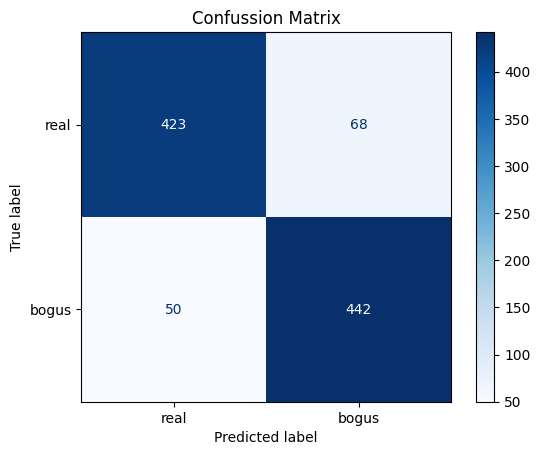


               ===== Classification report =====
              precision    recall  f1-score   support

        real       0.89      0.86      0.88       491
       bogus       0.87      0.90      0.88       492

    accuracy                           0.88       983
   macro avg       0.88      0.88      0.88       983
weighted avg       0.88      0.88      0.88       983



In [21]:
# Display the model performance metrics
loss_base, acc_base = base_model.evaluate(X_test, y_test)
print("Accuracy:", acc_base)
metrics_base = evaluate_cnn_model(base_model, X_test, y_test)

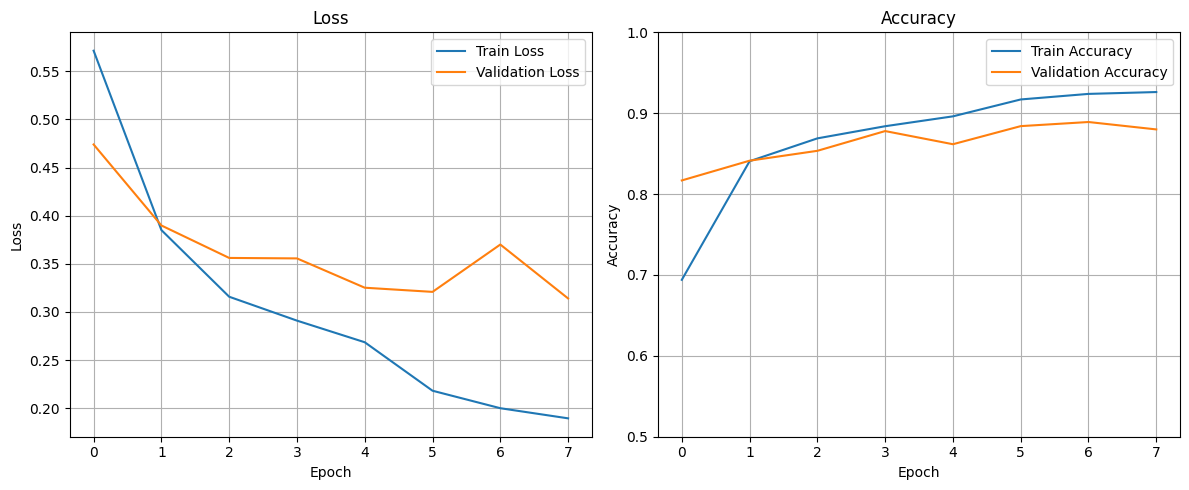

In [22]:
# Plot loss and accuracy visualization
plot_training_history(history_base)

The model achieves an overall accuracy of approximately 90%, demonstrating strong predictive capability well above random guessing. It exhibits high effectiveness to identify correct astronomical objects is high, as is its ability to identify both real and bogus objects. In the astronomy field, maximing the Recalll (or F1-score as well) for the real class is critical, as missinng true discoveries (false negatives such as ignoring a supernova explotion) carries a high science lost. In fact, the baseline model concentrating more false negative errors than false positives, therefore, this is a clear area for improvement.

Regarding the visualizations, the training loss decreases steadily throughout the epochs. However, the validation loss curve begins to diverge from epoch 2 onward, reaching its maximum gap at the final epoch, which provides clear evidence of overfitting. While the training and validation accuracy curves reamin close, a slight divergence emerges near the end, reinforcing the overfitting and epoch limit discussion.


Overall, we achieved competitive results for a lightweight baseline model on a limited dataset. Moving forward, Our goal going forward, beyond further improving predictive performance, our primary goal is to ensure consistencia across evaluation metrics which involvess enhancing model generaization, mitigating overfitting, and narrowing the gap between training and validation loss curves.

  


## Optimization

### Data Augmentation and Dropout

With the baseline model established, we now evaluate the impact of techniques such as data augmentation (artificially expanding  the dataset through flips, crops, and rotation of the images) and dropout (randomly deactivating neurons during training to prevent overfitting  and prioritize general feature representation) on stabilizing and improving our model:

In [9]:
# Baseline plus data augmentation and dropout
def baseline_cnn_plus(input_shape=(63, 63, 3), num_classes=10):
    model = models.Sequential()

    data_augmentation = tf.keras.Sequential([ #aug
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.1, 0.1),
    ])


    # Convolutional layers
    model.add(data_augmentation) # plus data via augmentation

    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    #model.add(layers.BatchNormalization())  
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25)) # dropout

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    #model.add(layers.BatchNormalization())  
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25)) # dropout

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    #model.add(layers.BatchNormalization())  

    # Dense layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    

    # This block is used for the multiclass extension in notebook III
    if num_classes <= 2:
        # Binary (Real vs Bogus) SIGMOIDE activation (used in this notebook)
        n_cat = 1
        activation = 'sigmoid'
        loss = 'binary_crossentropy'

    else:
        # Multiclass (3+) SOFTMAX activation
        n_cat = num_classes
        activation = 'softmax'
        loss = 'sparse_categorical_crossentropy' # simple label 0,1,2

    # Its depends on multiclass o binary classification
    model.add(layers.Dense(n_cat, activation=activation))

    model.compile(
        optimizer='adam',
        loss=loss,
        metrics=['accuracy']
    )
    return model

Since regularization techniques such as data augmentation and dropout mitigate the risk of overfitting, the numbers of training epochs is setted higher to allow the network more time to achieve convergence and improve accuracy. Additionally, we implemented early stopping with a patience of 5 epochs to automatically halt training once the validation loss stabilizes, preventing extra computation. 

In [10]:
# training model
model_plus = baseline_cnn_plus(input_shape=(63,63,3), num_classes=2)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_plus = model_plus.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32, # small dataset
    callbacks=[early_stop]
)

# architecture
model_plus.summary()

c:\Users\Paul\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.5751 - loss: 0.6452 - val_accuracy: 0.6539 - val_loss: 0.6115
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.7091 - loss: 0.5265 - val_accuracy: 0.7723 - val_loss: 0.5132
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.7858 - loss: 0.4652 - val_accuracy: 0.7608 - val_loss: 0.4710
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.8205 - loss: 0.4471 - val_accuracy: 0.8308 - val_loss: 0.4386
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.8339 - loss: 0.4139 - val_accuracy: 0.8104 - val_loss: 0.4152
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8456 - loss: 0.3616 - val_accuracy: 0.8486 - val_loss: 0.3761
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8549 - loss: 0.3539 - val_accuracy: 0.8651 - val_loss: 0.3294
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.8542 - loss: 0.3425 - val_accuracy: 0.8384 - 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 63, 63, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,938,821 (7.40 MB)

 Trainable params: 646,273 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,292,548 (4.93 MB)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9217 - loss: 0.2127
Accuracy: 0.9216683506965637
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


<Figure size 800x600 with 0 Axes>

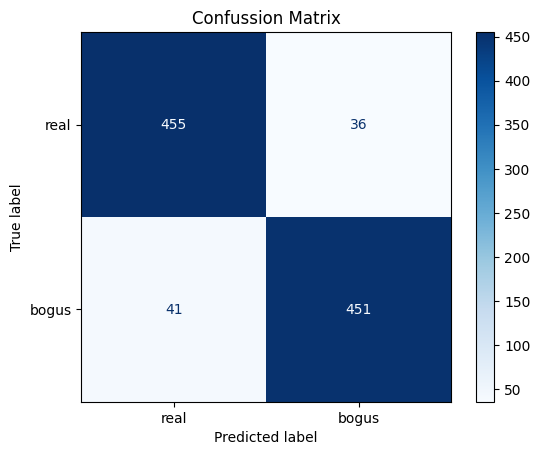


               ===== Classification report =====
              precision    recall  f1-score   support

        real       0.92      0.93      0.92       491
       bogus       0.93      0.92      0.92       492

    accuracy                           0.92       983
   macro avg       0.92      0.92      0.92       983
weighted avg       0.92      0.92      0.92       983



In [11]:
# Display the model performance metrics
loss_plus, acc_plus = model_plus.evaluate(X_test, y_test)
print("Accuracy:", acc_plus)
metrics_plus = evaluate_cnn_model(model_plus, X_test, y_test)

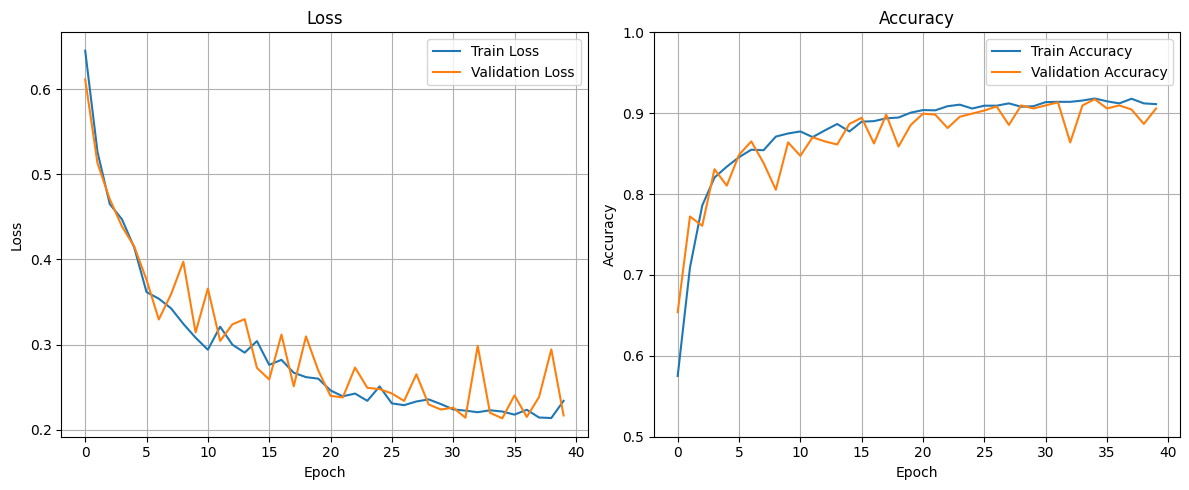

In [12]:
# Visualizations of the Loss and Accuracy
plot_training_history(history_plus)

The model shows a clerly improvement in accuracy, reaching approximately 92%. Classification performance is high across both classes, with precision and recall stabilizing in contrast to baseline model (with a gap of 20% in recall performance). Furthermore, we observe a better balance between false positive (FP) and false negative (FN) errors, with a reduction in the number of FN errors, the most scientifically error type in the study.

The visualizations also show clear improvement. The loss curves are much better stabilized and show no significant divergence, indicating that overfitting has been effectively mitigated. We attribute this stability directly to data augmentation, which expand our effective training set to up 100,000 synthetic samples, reducing the constraints of a small dataset. Addiotionally, dropout randomly deactivates neurons during training, preventing overfitting and forcing the network to learn more generalized features (this yield better performance on the unseen test set, $X_{test}$).


### Transfer Learning



We investigate the feasibility of transfer learning for astronomical real/bogus classification by applying weights previously trained on millions of data points applied to our baseline model. We will analyze the domain effectiveness of transfer learning by comparing two approaches: on the one hand, using MobileNetV2 weights as an external domain (learned from ImageNet), and on the other hand, using weights from the Braai architecture, a Real/Bogus classifier trained on millions of ZFT stamps (just like the baseline CNN) as an identical specific domain.

#### MobileNetV2



We loaded a pre-trained MobileNetV2 architecture, removing its final 1000-class classification layer and freezing the pre-trained weights. Then, we appended a binary classification top layer to adapt the architecture to our real/bogus task. Consequently, MobileNetV2 only serves as a feature extractor (the ability to detect low-level edges, shapes, and complex patterns, without performing the final decision)

In [13]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False, # The last layer is used for +1000 class
    input_shape=(63, 63, 3)
)

# Freeze all baseline layers (no modify the weights loaded)
base_model.trainable = False

C:\Users\Paul\AppData\Local\Temp\ipykernel_30440\2801237531.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [ ]:
# Add layers for baseline data
inputs = layers.Input(shape=(63, 63, 3))
x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)
net_model = models.Model(inputs, outputs)

net_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
# Model training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_net = net_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.7199 - loss: 0.6175 - val_accuracy: 0.7532 - val_loss: 0.4824
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.7693 - loss: 0.4812 - val_accuracy: 0.8003 - val_loss: 0.4548
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.7868 - loss: 0.4596 - val_accuracy: 0.7723 - val_loss: 0.4701
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.7810 - loss: 0.4616 - val_accuracy: 0.7863 - val_loss: 0.4653
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.7963 - loss: 0.4320 - val_accuracy: 0.8041 - val_loss: 0.4348
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.7938 - loss: 0.4315 - val_accuracy: 0.7926 - val_loss: 0.4562
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.7938 - loss: 0.4241 - val_accuracy: 0.8066 - val_loss: 0.4363
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.8049 - loss: 0.4213 - val_accuracy: 0.801

In [17]:
# Architecture
net_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 63, 63, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,664 (10.49 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,454 (1.25 MB)

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8159 - loss: 0.3965
Accuracy: 0.8158698081970215
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step


<Figure size 800x600 with 0 Axes>

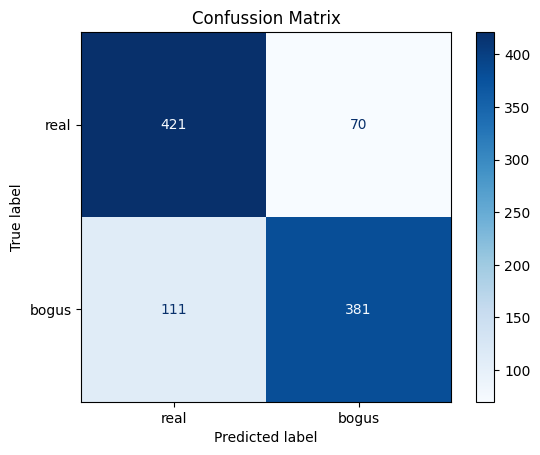


               ===== Classification report =====
              precision    recall  f1-score   support

        real       0.79      0.86      0.82       491
       bogus       0.84      0.77      0.81       492

    accuracy                           0.82       983
   macro avg       0.82      0.82      0.82       983
weighted avg       0.82      0.82      0.82       983



In [16]:
# Display some metrics
loss_net, acc_net = net_model.evaluate(X_test, y_test)
print("Accuracy:", acc_net)
metrics_net = evaluate_cnn_model(net_model, X_test, y_test)




The transfer learning model achieved decent overall performance, particularly given that only the classification head was trained to adapt to our dataset. ImageNet features transferred reasonably well despite being a totally different domain (between natural images and astronomical stamps). However, the false negative (FN) rate remains critically high compared to prior architectures trained.

### Braai

In [25]:
# Baseline plus with Braai as feature extractor
def baseline_tl(model_fe, input_shape=(63, 63, 3), num_classes=10):
    model = models.Sequential()

    # Instead our layers we use Braai
    model.add(model_fe) # Braai model as features
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.25))

    # This block is used for the multiclass extension in notebook III
    if num_classes <= 2:
        # Binary (Real vs Bogus) SIGMOIDE activation (used in this notebook)
        n_cat = 1
        activation = 'sigmoid'
        loss = 'binary_crossentropy'

    else:
        # Multiclass (3+) SOFTMAX activation
        n_cat = num_classes
        activation = 'softmax'
        loss = 'sparse_categorical_crossentropy' # simple label 0,1,2

    # Its depends on multiclass o binary classification
    model.add(layers.Dense(n_cat, activation=activation))

    model.compile(
        optimizer='adam',
        loss=loss,
        metrics=['accuracy']
    )
    return model

In [26]:
from utils_braai import load_model_helper

In [27]:
# Load Braai model
braai_base = load_model_helper(path='../models', model_base_name='braai_d6_m9')

# Use the model only for feature extractor 
model_fe = tf.keras.Model(inputs=braai_base.inputs, outputs=braai_base.layers[-2].output)
for layer in model_fe.layers:
    layer.trainable = False

model_tl = baseline_tl(model_fe=model_fe, num_classes=2)

In [28]:
model_tl.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_2 (Functional)        (None, 256)               311824    
                                                                 
 dense_6 (Dense)             (None, 64)                16448     
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 1)                 65        
                                                                 
Total params: 328337 (1.25 MB)
Trainable params: 16513 (64.50 KB)
Non-trainable params: 311824 (1.19 MB)
_________________________________________________________________


In [30]:
# Model training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_plus = model_tl.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32, # small dataset
    callbacks=[early_stop]
)

Epoch 1/50
99/99 [==============================] - 3s 22ms/step - loss: 0.6570 - accuracy: 0.5831 - val_loss: 0.6202 - val_accuracy: 0.6921
Epoch 2/50
99/99 [==============================] - 2s 21ms/step - loss: 0.6286 - accuracy: 0.6423 - val_loss: 0.6057 - val_accuracy: 0.6883
Epoch 3/50
99/99 [==============================] - 2s 23ms/step - loss: 0.6096 - accuracy: 0.6763 - val_loss: 0.5766 - val_accuracy: 0.7265
Epoch 4/50
99/99 [==============================] - 2s 24ms/step - loss: 0.5947 - accuracy: 0.6865 - val_loss: 0.5651 - val_accuracy: 0.7366
Epoch 5/50
99/99 [==============================] - 2s 25ms/step - loss: 0.5863 - accuracy: 0.6951 - val_loss: 0.5568 - val_accuracy: 0.7468
Epoch 6/50
99/99 [==============================] - 2s 21ms/step - loss: 0.5719 - accuracy: 0.7091 - val_loss: 0.5522 - val_accuracy: 0.7405
Epoch 7/50
99/99 [==============================] - 2s 21ms/step - loss: 0.5713 - accuracy: 0.7072 - val_loss: 0.5485 - val_accuracy: 0.7455
Epoch 8/50
99

31/31 [==============================] - 0s 14ms/step - loss: 0.4666 - accuracy: 0.7762
Accuracy: 0.7761953473091125
31/31 [==============================] - 1s 16ms/step


<Figure size 800x600 with 0 Axes>

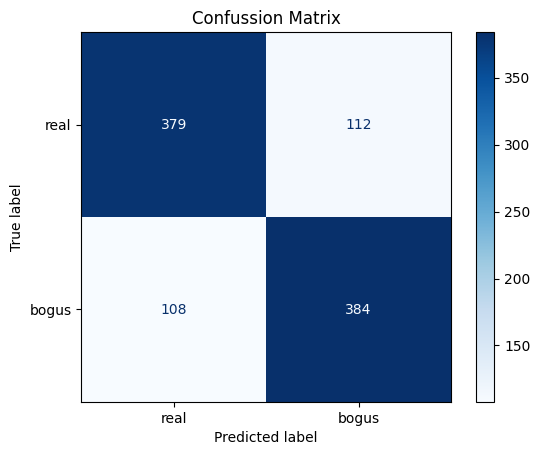


               ===== Classification report =====
              precision    recall  f1-score   support

        real       0.78      0.77      0.78       491
       bogus       0.77      0.78      0.78       492

    accuracy                           0.78       983
   macro avg       0.78      0.78      0.78       983
weighted avg       0.78      0.78      0.78       983



In [31]:
# Display the model performance metrics
loss_tl, acc_tl = model_tl.evaluate(X_test, y_test)
print("Accuracy:", acc_tl)
metrics_plus = evaluate_cnn_model(model_tl, X_test, y_test)